# Import

In [1]:
from pathlib import Path
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch


ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

In [2]:
from brighteyes_flim import mcs
from brighteyes_flim import flism
from brighteyes_flim.flism import Alignment

print(mcs.__file__)
print(flism.__file__)


/home/mdonato/.local/share/mamba/envs/venv-3.10/lib/python3.10/site-packages/brighteyes_ism/dataio/mcs.py
/home/mdonato/myDev/BrightEyes-Flim-GIT/src/brighteyes_flim/flism.py


# Imported helpers

In [3]:

IRF_from_data_deconvolution = Alignment.IRF_from_data_deconvolution
fit_model_data = Alignment.fit_model_data
hist_for_plot = Alignment.hist_for_plot
perform_fit_data = Alignment.perform_fit_data
phasor_delay_from_hist = Alignment.phasor_delay_from_hist

# Tests
It this thest we want to generate by simulation the data, the irf and the reference measurements. All of them with a different delay from the T/2 time point.


# Processing (Data and Reference) EXP

From here we assume that we have the Data (data_sim) and the Reference (ref_sim) datasets and we simply know that the Reference is a single-exponential decay from which we know the fluorescence lifetime tau_R

Given the fact that we know that the reference is a single-exponential decay and we know the lifetime tau_R, we can deconvolve the reference dataset to estimate irf for this specific measurement. We call it est_irf_ref to distinguish from the irf_sim, which is a simulated irf dataset, and irf which is the noise-free (and centered in T/2) irf used for all simulation

In [4]:
f_ref = "/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/FLIMLABS_Yellow_slide_2_5ns-17-03-2026-16-18-22.h5"
tau_R = 2.5

f_data = "/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/01_Convallaria_DFD_40MHz-17-03-2026-16-59-41.h5"


ref, metadata_ref = mcs.load(f_ref)
data, metadata_data = mcs.load(f_data)

#print(a[1].dfd_activate)
#print(a[1].dfd_freq)
#print(a[1].dfd_nbins)

ref=ref[0,0,:,:,:,12].sum(axis=(0,1))
data=data[0,0,:,:,:,12].sum(axis=(0,1))
ref=np.roll(ref, 50) # shift reference to the left by 40 bins to roughly align with data

nbin = metadata_data.dfd_nbins 
freq = metadata_data.dfd_freq * 1e6

period = 1/freq * 1e9 # ns
dt = period/nbin # ns
print(f"dt = {dt} ns, period = {period} ns")
t = np.arange(nbin)*dt
C = 1e3
C_R = 3e3
#dT = 50*dt
#dT_R = 4*dt #delay of the reference with respect to T/2 in ns
#dT_I = 6*dt #delay of the irf with respect to T/2 in ns
#dT_D = 10*dt #delay of the data with respect to T/2 in ns



ref.shape

dt = 0.27472527472527475 ns, period = 25.0 ns


(91,)

In [5]:
est_irf_ref = IRF_from_data_deconvolution(ref, t, C_R, tau_R, period, iterations=300)

norm_est_irf_ref = est_irf_ref / torch.sum(est_irf_ref)

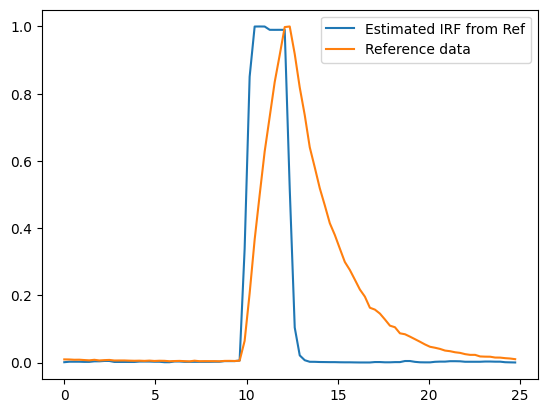

In [6]:
plt.plot(t, est_irf_ref/max(est_irf_ref), label='Estimated IRF from Ref')
plt.plot(t, ref/max(ref), label='Reference data')
plt.legend()
plt.show()

In [7]:
pout, conv = perform_fit_data(t, data, est_irf_ref, period)
C_fit_data, dT_fit_data, tau_fit_data = pout["C"], pout["dT"], pout["tau"]

fitted_data = fit_model_data(t, **pout, irf=est_irf_ref, period=period)

deltaT_data_ref = np.mod(dT_fit_data, period)




We fit the Reference dataset with the estimated irf to double check the compatibility. We expected to find the tau equal to tau_R imposed and as the delay dT equal to zero since Reference dataset and estimated irf are not shifted one respect to each other

Now we fit the Data dataset with the irf estimated from the reference

In [8]:
pout, conv = perform_fit_data(t, data, est_irf_ref, period)
C_fit_data, dT_fit_data, tau_fit_data = pout["C"], pout["dT"], pout["tau"]

fitted_data = fit_model_data(t, **pout, irf=est_irf_ref, period=period)

deltaT_data_ref = np.mod(dT_fit_data*dt, period)


print(f"C_fit data   = {C_fit_data}")
print(f"dT_fit data in ns  = {dT_fit_data*dt}")
print(f"tau_fit data = {tau_fit_data}")
print(f"delay between data and reference = {deltaT_data_ref}")

C_fit data   = 3.0796072740042035
dT_fit data in ns  = 9.890109820609963
tau_fit data = 1.176965297692631
delay between data and reference = 9.890109820609963


dT_fit_data should be equal to the delay of the data dataset and the reference dataset and not the delay of the data dataset with respect to T/2

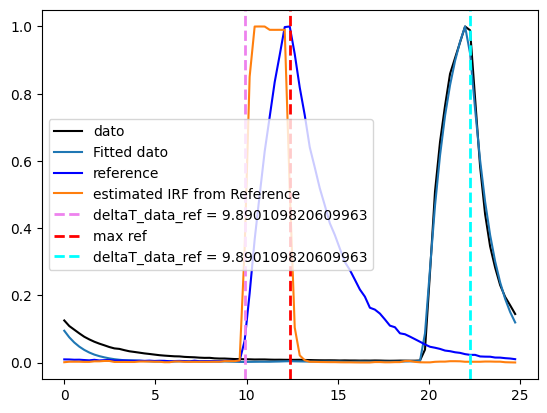

In [9]:
plt.plot(t, data/max(data), label='dato', color='black')
plt.plot(t, fitted_data/max(fitted_data), label='Fitted dato')

plt.plot(t, ref/max(ref), label='reference', color='blue')
plt.plot(t, est_irf_ref/max(est_irf_ref), label='estimated IRF from Reference')
plt.legend()

plt.axvline(x=deltaT_data_ref, linestyle='--', color ='violet', linewidth=2, label=f"deltaT_data_ref = {deltaT_data_ref}")

t_ref_max = np.mod(t[ref.argmax()],period)
plt.axvline(x=t_ref_max, linestyle='--', color ='red', linewidth=2, label=f"max ref")

t_ref_max = np.mod(t[ref.argmax()]+deltaT_data_ref,period)
plt.axvline(x=t_ref_max, linestyle='--', color ='cyan', linewidth=2, label=f"deltaT_data_ref = {deltaT_data_ref}")


plt.legend()



IRF phase = 2.8090 rad, delay = 11.1766 ns
DATA phase = 5.6040 rad, delay = 22.2978 ns
Delta(DATA - IRF) = 11.1212 ns


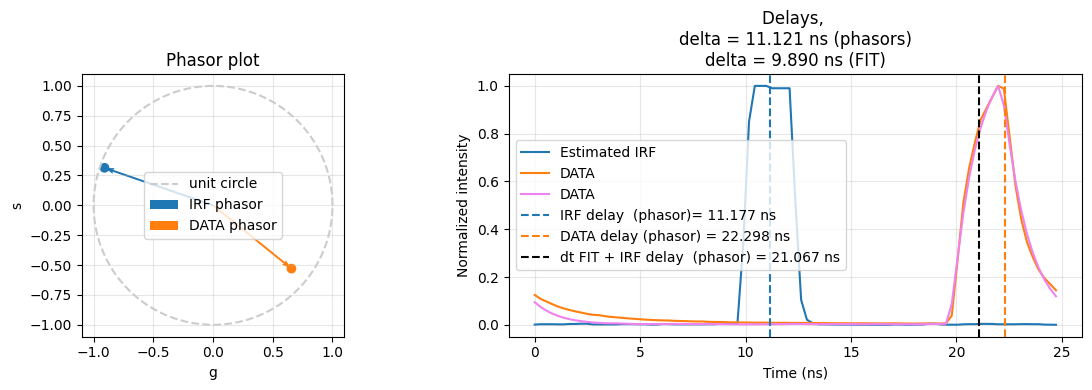

In [10]:
irf_hist = hist_for_plot(est_irf_ref)
data_hist = hist_for_plot(data)

phasor_irf, phase_irf_rad, delay_irf_ns = phasor_delay_from_hist(irf_hist, period)
phasor_data, phase_data_rad, delay_data_ns = phasor_delay_from_hist(data_hist, period)
delta_delay_ns = np.mod(delay_data_ns - delay_irf_ns, period)

print(f"IRF phase = {phase_irf_rad:.4f} rad, delay = {delay_irf_ns:.4f} ns")
print(f"DATA phase = {phase_data_rad:.4f} rad, delay = {delay_data_ns:.4f} ns")
print(f"Delta(DATA - IRF) = {delta_delay_ns:.4f} ns")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

theta = np.linspace(0, 2 * np.pi, 400)
axes[0].plot(np.cos(theta), np.sin(theta), '--', color='0.8', label='unit circle')
axes[0].quiver(0, 0, np.real(phasor_irf), np.imag(phasor_irf), angles='xy', scale_units='xy', scale=1, color='tab:blue', label='IRF phasor')
axes[0].quiver(0, 0, np.real(phasor_data), np.imag(phasor_data), angles='xy', scale_units='xy', scale=1, color='tab:orange', label='DATA phasor')
axes[0].scatter([np.real(phasor_irf), np.real(phasor_data)], [np.imag(phasor_irf), np.imag(phasor_data)], color=['tab:blue', 'tab:orange'])
axes[0].set_xlabel('g')
axes[0].set_ylabel('s')
axes[0].set_title('Phasor plot')
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

delay_data_ns_fit = np.mod(delay_irf_ns+deltaT_data_ref,period)

axes[1].plot(t, irf_hist / irf_hist.max(), label='Estimated IRF', color='tab:blue')
axes[1].plot(t, data_hist / data_hist.max(), label='DATA', color='tab:orange')
axes[1].plot(t, fitted_data / fitted_data.max(), label='DATA', color='violet')
axes[1].axvline(delay_irf_ns, linestyle='--', color='tab:blue', label=f'IRF delay  (phasor)= {delay_irf_ns:.3f} ns')
axes[1].axvline(delay_data_ns, linestyle='--', color='tab:orange', label=f'DATA delay (phasor) = {delay_data_ns:.3f} ns')
axes[1].axvline(delay_data_ns_fit, linestyle='--', color='k', label=f'dt FIT + IRF delay  (phasor) = {delay_data_ns_fit:.3f} ns')
axes[1].set_xlabel('Time (ns)')
axes[1].set_ylabel('Normalized intensity')
axes[1].set_title(f'Delays, \ndelta = {delta_delay_ns:.3f} ns (phasors)\ndelta = {deltaT_data_ref:.3f} ns (FIT)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()


plt.tight_layout()
plt.show()


roll_shift_bins | roll_shift_ns | dT_fit_ns | tau_fit_ns | phasor_delta_ns
              0 |         0.000 |    23.626 |      1.185 |          24.858
              1 |         0.275 |    23.352 |      1.184 |          24.583
              2 |         0.549 |    23.077 |      1.185 |          24.308
              3 |         0.824 |    22.802 |      1.183 |          24.033
              4 |         1.099 |    22.527 |      1.182 |          23.759
              5 |         1.374 |    22.253 |      1.177 |          23.484
              6 |         1.648 |    21.978 |      1.175 |          23.209
              7 |         1.923 |    21.703 |      1.176 |          22.934
              8 |         2.198 |    21.429 |      1.178 |          22.660
              9 |         2.473 |    21.154 |      1.184 |          22.385
             10 |         2.747 |    20.879 |      1.178 |          22.110
             11 |         3.022 |    20.604 |      1.185 |          21.836
             12 |        

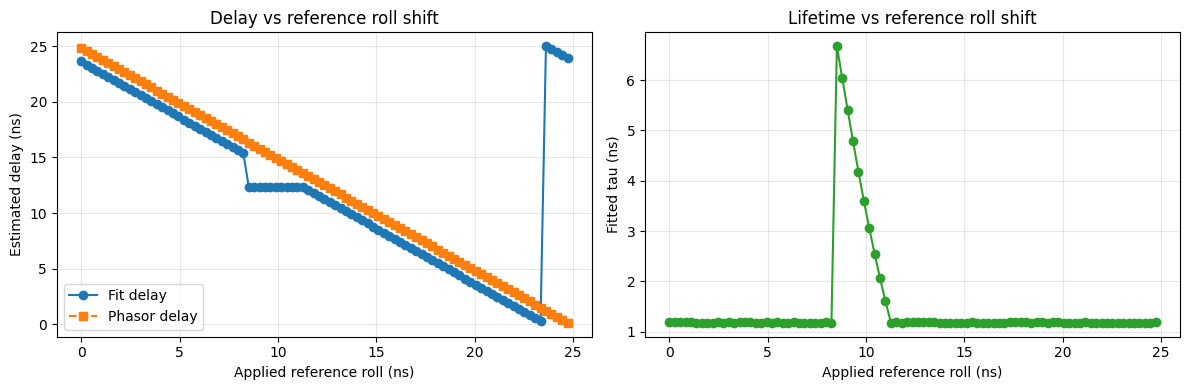

In [11]:
# Repeat the same workflow for multiple reference shifts.
# Edit `roll_shifts` as needed. Example single value: [10]
roll_shifts = list(range(0, nbin, 1))

with h5py.File(f_ref, 'r') as hf_ref:
    ref_raw = hf_ref['data'][0, 0, :, :, :, 12].sum(axis=(0, 1))

with h5py.File(f_data, 'r') as hf_data:
    data_raw = hf_data['data'][0, 0, :, :, :, 12].sum(axis=(0, 1))

scan_results = []

for roll_shift in roll_shifts:
    ref_shifted = np.roll(ref_raw, roll_shift)  # example: np.roll(ref_raw, 10)

    est_irf_ref_loop = IRF_from_data_deconvolution(ref_shifted, t, C_R, tau_R, period, iterations=300)
    pout_loop, _ = perform_fit_data(t, data_raw, est_irf_ref_loop, period)
    fitted_data_loop = fit_model_data(t, **pout_loop, irf=est_irf_ref_loop, period=period)

    deltaT_fit_ns = np.mod(pout_loop['dT'] * dt, period)

    irf_hist_loop = hist_for_plot(est_irf_ref_loop)
    data_hist_loop = hist_for_plot(data_raw)
    _, _, delay_irf_ns_loop = phasor_delay_from_hist(irf_hist_loop, period)
    _, _, delay_data_ns_loop = phasor_delay_from_hist(data_hist_loop, period)
    delta_delay_ns_loop = np.mod(delay_data_ns_loop - delay_irf_ns_loop, period)

    scan_results.append({
        'roll_shift_bins': roll_shift,
        'roll_shift_ns': roll_shift * dt,
        'dT_fit_ns': deltaT_fit_ns,
        'tau_fit_ns': pout_loop['tau'],
        'phasor_delta_ns': delta_delay_ns_loop,
        'ref_max_ns': np.mod(t[ref_shifted.argmax()], period),
        'fitted_data_peak_ns': np.mod(t[hist_for_plot(fitted_data_loop).argmax()], period),
    })

print('roll_shift_bins | roll_shift_ns | dT_fit_ns | tau_fit_ns | phasor_delta_ns')
for row in scan_results:
    print(
        f"{row['roll_shift_bins']:15d} | "
        f"{row['roll_shift_ns']:13.3f} | "
        f"{row['dT_fit_ns']:9.3f} | "
        f"{row['tau_fit_ns']:10.3f} | "
        f"{row['phasor_delta_ns']:15.3f}"
    )

roll_shift_ns = [row['roll_shift_ns'] for row in scan_results]
dT_fit_ns = [row['dT_fit_ns'] for row in scan_results]
phasor_delta_ns = [row['phasor_delta_ns'] for row in scan_results]
tau_fit_ns = [row['tau_fit_ns'] for row in scan_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(roll_shift_ns, dT_fit_ns, 'o-', label='Fit delay')
axes[0].plot(roll_shift_ns, phasor_delta_ns, 's--', label='Phasor delay')
axes[0].set_xlabel('Applied reference roll (ns)')
axes[0].set_ylabel('Estimated delay (ns)')
axes[0].set_title('Delay vs reference roll shift')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(roll_shift_ns, tau_fit_ns, 'o-', color='tab:green')
axes[1].set_xlabel('Applied reference roll (ns)')
axes[1].set_ylabel('Fitted tau (ns)')
axes[1].set_title('Lifetime vs reference roll shift')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
